In [1]:
import pandas as pd

df = pd.read_csv("sensitivity.csv")
tags = pd.read_csv("Games Sales Curve Categorizations - tags.csv")

In [2]:
tags

,product,curve_category
0,Twelve Minutes,"front-loaded, no-presale"
1,Ashen,presale
2,Maquette,"front-loaded, linear, low perf, no-presale"
3,Open Roads,"front-loaded, low perf, no-presale"
4,Thirsty Suitors,"front-loaded, low perf, no-presale"
5,Lorelei and the Laser Eyes,"front-loaded, secondary-surge, no-presale"
6,Cocoon,"front-loaded, presale"
7,Donut County,"linear, presale"
8,Due Process,"front-loaded, presale"
9,Storyteller,"front-loaded, secondary-surge, no-presale"


In [3]:
one_year = df.query("Weeks_from_Release <=52")
six_months = df.query("Weeks_from_Release <=26")

LT = df

In [4]:
#df = df.drop_duplicates('product', keep='last')
LT = LT.drop_duplicates('product', keep='last')
one_year = one_year.drop_duplicates('product', keep='last')
six_months = six_months.drop_duplicates('product', keep='last')

In [5]:
data = LT.merge(tags, on='product')
data_one_year = one_year.merge(tags, on='product')
data_six_months = six_months.merge(tags, on='product')
data_LT = LT.merge(tags, on='product')


In [6]:
data = data.fillna("")

In [7]:
import ast
data['curve_category'] = data['curve_category'].apply(lambda x: x.split(', '))

In [8]:
cat_df = data.explode('curve_category')

In [9]:
cat_df.groupby("curve_category").units.describe().round(0)/1000

,count,mean,std,min,25%,50%,75%,max
curve_category,,,,,,,,
,0.004,38.061,20.984,18.320,27.060,33.239,44.240,67.445
front-loaded,0.018,532.974,1499.709,8.796,58.526,131.820,304.971,6504.177
high perf,0.005,2980.318,2121.481,1016.683,1756.488,2516.362,3107.881,6504.177
linear,0.015,745.551,993.974,12.057,50.202,177.650,1103.906,3107.881
low perf,0.012,41.087,28.198,8.796,13.192,39.864,64.286,92.803
no-presale,0.018,210.684,284.308,8.796,23.202,66.977,340.518,1016.683
presale,0.015,1162.642,1758.804,56.794,153.370,312.744,1473.808,6504.177
secondary-surge,0.010,630.667,1017.196,8.796,66.477,123.586,533.041,3107.881


In [10]:
data_one_year.rename({'Weeks_from_Release':'Weeks_from_Release_first_year', 'units':'units_first_year'},axis=1, inplace=True)
data_one_year = data_one_year[['product', 'Weeks_from_Release_first_year', 'units_first_year']]

data_one_year

,product,Weeks_from_Release_first_year,units_first_year
0,A Memoir Blue,52.0,16713
1,Ashen,52.0,192533
2,Cocoon,52.0,226649
3,Donut County,52.0,191425
4,Due Process,52.0,135839
5,Flock,44.0,8796
6,Florence,52.0,125541
7,Flower,52.0,50270
8,Gorogoa,52.0,186908
9,Hindsight,52.0,6330


In [11]:
data_six_months.rename({'Weeks_from_Release':'Weeks_from_Release_6month', 'units':'units_6month'},axis=1, inplace=True)
data_six_months = data_six_months[['product', 'Weeks_from_Release_6month', 'units_6month']]
data_six_months

,product,Weeks_from_Release_6month,units_6month
0,A Memoir Blue,26.0,11029
1,Ashen,26.0,152208
2,Cocoon,26.0,166944
3,Donut County,26.0,139824
4,Due Process,26.0,111927
5,Flock,26.0,7347
6,Florence,26.0,69541
7,Flower,26.0,31888
8,Gorogoa,26.0,105436
9,Hindsight,26.0,3652


In [12]:
data_LT.rename({'Weeks_from_Release':'Weeks_from_Release_LT', 'units':'units_LT'},axis=1, inplace=True)

final  = data_LT.merge(data_six_months, on='product')
final  = final.merge(data_one_year, on='product')

In [13]:
final['first_year_ratio'] = final['units_first_year'] / final['units_LT']
final['first_6month_ratio'] = final['units_6month'] / final['units_LT']
final['6month_to_year'] = final['units_6month'] / final['units_first_year']
final['diff_between_year'] = final['first_6month_ratio'] - final['first_year_ratio']

In [14]:
final[['product', 'units_LT','units_first_year','units_6month','first_year_ratio','first_6month_ratio','6month_to_year','diff_between_year']].sort_values("first_year_ratio", ascending=False)

,product,units_LT,units_first_year,units_6month,first_year_ratio,first_6month_ratio,6month_to_year,diff_between_year
5,Flock,8796,8796,7347,1.000000,0.835266,0.835266,-0.164734
34,Wanderstop,67445,67445,67445,1.000000,1.000000,1.000000,0.000000
24,Skin Deep,18320,18320,18320,1.000000,1.000000,1.000000,0.000000
17,Lushfoil Photography Sim,36505,36505,36505,1.000000,1.000000,1.000000,0.000000
16,Lorelei and the Laser Eyes,100514,100514,46367,1.000000,0.461299,0.461299,-0.538701
21,Open Roads,18897,18073,14529,0.956395,0.768852,0.803906,-0.187543
4,Due Process,160082,135839,111927,0.848559,0.699185,0.823968,-0.149373
32,Thirsty Suitors,13239,11186,8487,0.844928,0.641061,0.758716,-0.203867
2,Cocoon,281652,226649,166944,0.804713,0.592731,0.736575,-0.211981
26,Storyteller,571751,457589,276270,0.800329,0.483200,0.603751,-0.317129


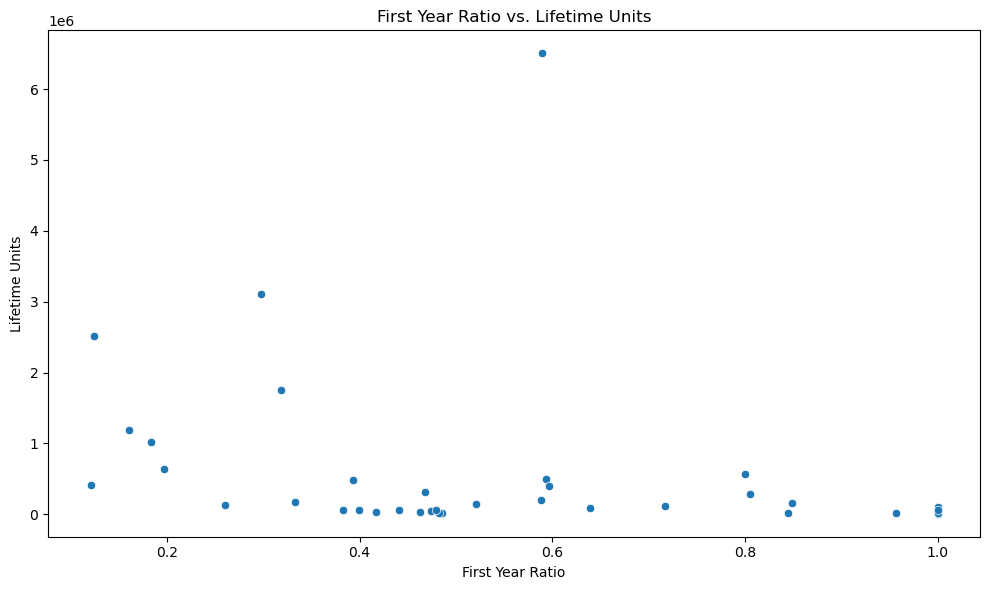

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=final, x='first_year_ratio', y='units_LT')

# Add labels and title
plt.xlabel('First Year Ratio')
plt.ylabel('Lifetime Units')
plt.title('First Year Ratio vs. Lifetime Units')

plt.tight_layout()
plt.show()

In [16]:
final = final.fillna("")

In [17]:
final['curve_category'] = final['curve_category'].apply(lambda x: x.split(', '))

In [18]:
final_tags = final.explode('curve_category')

In [19]:
final_tags.groupby("curve_category").first_year_ratio.mean()

curve_category
                   0.854119
front-loaded       0.684500
high perf          0.302659
linear             0.315920
low perf           0.587324
no-presale         0.527773
presale            0.497525
secondary-surge    0.536175
Name: first_year_ratio, dtype: float64